In [145]:
import os 
import numpy as np
import PIL.Image as Image
import PIL.ImageOps as ImageOps
import matplotlib.pyplot as plt 
import pandas as pd
import math
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset , DataLoader , random_split
import torchvision.transforms as transforms
import pickle as pk
OUTPUT_DIR = '/kaggle/working/'
train_input_dir = '/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/train'
train_images_dir = os.path.join(train_input_dir , "images")
train_masks_dir  = os.path.join(train_input_dir , "masks")

test_input_dir = '/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/test'
test_images_dir = os.path.join(test_input_dir , "images")
test_masks_dir  = os.path.join(test_input_dir , "masks")

In [112]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [113]:
class dataset(Dataset):
    def __init__(self , dataset_type , images_dir , masks_dir , Transform = None , mask_transform = None):
        self.dataset_type = dataset_type
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.images = os.listdir(images_dir)
        self.length = len(self.images)
        self.Transform = Transform
    
    def __len__(self):
        return self.length

    def __getitem__(self , idx):
        
        image_name = self.images[idx]
        mask_name = image_name.replace(".jpg" , ".png")
        image_path = os.path.join(self.images_dir , image_name)
        mask_path =  os.path.join(self.masks_dir , mask_name)

        
        image = ImageOps.grayscale(Image.open(image_path))
        
        PIL_MASK = Image.open(mask_path)
        if mask_transform :
            PIL_MASK =  mask_transform(PIL_MASK)
        
        mask_tensor = torch.Tensor(np.array(PIL_MASK) ).unsqueeze(0) / 255

        
        h , w = image.size
        
        if h < 256 or w < 256:
            idx = (idx + 1) % self.length
            image , mask_tensor = self.__getitem__(idx)
        else:
            if self.Transform:
                image = self.Transform(image)
                
        return image , mask_tensor

    def get_images(self):
        return self.images


In [114]:
image_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(256),
    transforms.ToTensor()
])

In [115]:
mask_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(256),
])

In [116]:
train_dataset = dataset('train', train_images_dir , train_masks_dir , Transform = image_transform  , mask_transform = mask_transform)
test_dataset = dataset('test' , test_images_dir , test_masks_dir , Transform = image_transform , mask_transform = mask_transform)

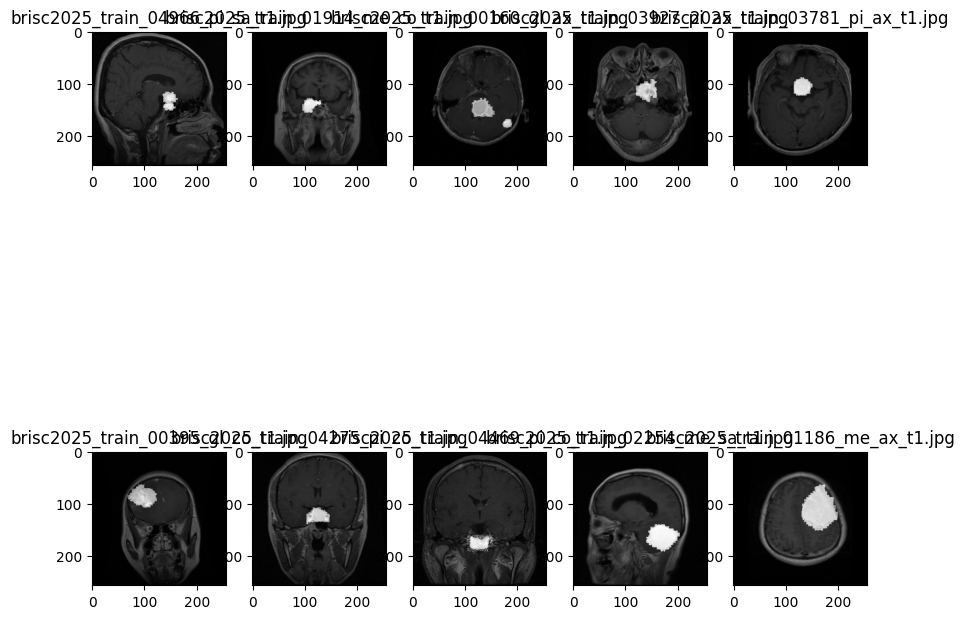

In [117]:
N = 10

def plot_images(dataset , N = 5 , with_mask = True , seed = 1):


    fig = plt.figure(figsize = (10 , 10))

    for i in range(N):
        ax = fig.add_subplot(2 , math.ceil(N / 2) , i + 1)
        
        data = dataset[i]

        title = dataset.get_images()[i]
        
        image_PIL = data[0]
        image_numpy = np.array(image_PIL)
        mask_numpy = np.array(data[1])
        
        
        if with_mask:
            mask = (mask_numpy > 0 ).astype('int') * 255
            mask = mask.reshape(mask.shape[1] , mask.shape[2] , 1 )
        else:
            mask = np.zeros(image_numpy.shape)
            mask = mask.reshape(mask.shape[0] , mask.shape[1] , 1)
        image_numpy = image_numpy.reshape(image_numpy.shape[0] , image_numpy.shape[1] , 1)
        
        ax.imshow(image_numpy  + mask , cmap = 'gray')
        ax.set_title(title)


train_dataset_plot = dataset('train', train_images_dir , train_masks_dir , Transform = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(256)])  , mask_transform = mask_transform)
plot_images(train_dataset_plot , N = N , with_mask = True, seed = 5)

In [118]:
total_pixels = {'zeros' : 0 , 'ones' : 0 , 'total' : 0}
for image , target in train_dataset:
    target = (target > 0).int()
    total_pixels['ones'] += target.sum().item()
    total_pixels['total'] += math.prod(list(target.shape))
total_pixels['zeros'] = total_pixels['total'] - total_pixels['ones']

In [119]:
pos_weight = total_pixels['zeros']/total_pixels['ones']
pos_weight

47.88165944181322

In [120]:
batch_size = 16
train_dataloader = DataLoader(train_dataset , batch_size = batch_size , shuffle = True)
test_dataloader = DataLoader(test_dataset , batch_size = batch_size , shuffle = False )

# **Section 2 : Model Building (U-Net)**

In [121]:
class EncoderBlock(nn.Module):
    def __init__(self , in_channels  , out_channels , kernel_size = 3 , max_pooling = True):
        super().__init__()
        self.conv_1 = nn.Conv2d(in_channels , out_channels , kernel_size = kernel_size , stride = 1  , padding = 'same' )
        self.ReLU_1 = nn.ReLU()
        self.conv_2 = nn.Conv2d(out_channels , out_channels , kernel_size = kernel_size , stride = 1 , padding = 'same')
        self.ReLU_2 = nn.ReLU()
        self.max_pool = nn.MaxPool2d(kernel_size = 2 , stride = 2)
        self.max_pooling = max_pooling

    def forward(self , x):
        x = self.conv_1(x)
        x = self.ReLU_1(x)
        skip_connection = self.conv_2(x)
        skip_connection = self.ReLU_2(skip_connection)
        
        if self.max_pooling :
            next_kernel = self.max_pool(skip_connection)
        else:
            next_kernel = skip_connection

        return next_kernel , skip_connection

In [122]:
def crop(upsampled_kernel , skip_connection):
        m1 , c1 , h1 , w1 = skip_connection.shape
        m2 , c2 , h2 , w2 = upsampled_kernel.shape
        delta = h1 - h2
        if delta % 2 == 0:
            delta_1 = delta_2 = delta // 2
        else:
            delta_1 = delta // 2
            delta_2 = delta_1 + 1
        skip_connection_cropped = skip_connection[: , : , delta_1:(h1 - delta_2) , delta_1:(w1 - delta_2)]
        return upsampled_kernel , skip_connection_cropped

In [123]:
class DeconderBlock(nn.Module):
    def __init__(self , in_channels , out_channels , kernel_size = 3):
        super().__init__()
        self.transposeConv = nn.ConvTranspose2d(in_channels , out_channels , kernel_size = 2 , stride = 2)
        self.Conv_Block = EncoderBlock(in_channels , out_channels , max_pooling = False)
        

    def forward(self , previous_kernel , skip_connection):
        upsampled_kernel = self.transposeConv(previous_kernel)
        
        upsampled_kernel , skip_connection = crop(upsampled_kernel , skip_connection)
        
        result = torch.cat([upsampled_kernel , skip_connection] , dim = 1)
        result = self.Conv_Block(result)
        

        return result

In [124]:
class U_NET(nn.Module):
    def __init__(self , channels):
            super().__init__()
            # channels = 64
            self.ENBlock_1 = EncoderBlock(in_channels = 1 , out_channels = channels)
            self.ENBlock_2 = EncoderBlock(in_channels = channels , out_channels = channels * 2)
            self.ENBlock_3 = EncoderBlock(in_channels = channels * 2 , out_channels = channels * 2 * 2)
            self.ENBlock_4 = EncoderBlock(in_channels = channels * 2 * 2 , out_channels = channels * 2 * 2 * 2)
            self.ENBlock_5 = EncoderBlock(in_channels = channels * 2 * 2 * 2 , out_channels = channels * 2 * 2 * 2 * 2 , max_pooling = False)


            self.DEBlock_5 = DeconderBlock(in_channels = channels * 2 * 2 * 2 * 2 , out_channels = channels * 2 * 2 * 2 )
            self.DEBlock_4 = DeconderBlock(in_channels = channels * 2 * 2 * 2 , out_channels = channels * 2 * 2)
            self.DEBlock_3 = DeconderBlock(in_channels = channels * 2 * 2  , out_channels = channels * 2)
            self.DEBlock_2 = DeconderBlock(in_channels = channels * 2 , out_channels = channels)
            self.last_layer = nn.Conv2d(in_channels = channels , out_channels = 1 , kernel_size = 1 , stride = 1)
            self.sigmoid = nn.Sigmoid()

    def forward(self , x):
            next_kernel_1 , skip_connection_1 = self.ENBlock_1(x)
            next_kernel_2 , skip_connection_2 = self.ENBlock_2(next_kernel_1)
            next_kernel_3 , skip_connection_3 = self.ENBlock_3(next_kernel_2)
            next_kernel_4 , skip_connection_4 = self.ENBlock_4(next_kernel_3)
            next_kernel_5 , _ = self.ENBlock_5(next_kernel_4)
            
            
            next_kernel_6 , _= self.DEBlock_5(next_kernel_5 , skip_connection_4)
            next_kernel_7 , _ = self.DEBlock_4(next_kernel_6 , skip_connection_3)
            
            next_kernel_8 , _ = self.DEBlock_3(next_kernel_7 , skip_connection_2)
            next_kernel_9 , _ = self.DEBlock_2(next_kernel_8 , skip_connection_1)
            prediction = self.last_layer(next_kernel_9)
            return prediction

# Section 3 : Training 

In [125]:
model = nn.DataParallel(U_NET(channels = 16) , device_ids = [0 , 1])
model = model.to(device)

pos_weight_tensor = torch.tensor([pos_weight])
pos_weight_tensor = pos_weight_tensor.to(device)
pos_weight_tensor

tensor([47.8817], device='cuda:0')

In [126]:
loss_function = nn.BCEWithLogitsLoss(pos_weight = pos_weight_tensor)
optimizer = optim.Adam(model.parameters() , lr = 0.0001)

In [127]:
EPOCHS = 40
losses = []
for i in range(EPOCHS):
    batch_counter = 1
    total_loss = 0
    for inputs , labels in train_dataloader:
        print(f"epoch : {i + 1} | batch : {batch_counter} / {len(train_dataloader)}" , end ='\r' , flush = True)
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs , labels)
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
        
        batch_counter += 1
    avg_loss = total_loss / len(train_dataloader)
    print(f"EPOCH : {i + 1} | avg loss : {avg_loss}")
    losses.append(avg_loss)

EPOCH : 1 | avg loss : 0.9532312178999428
EPOCH : 2 | avg loss : 0.6353191438971496
EPOCH : 3 | avg loss : 0.5335903814653071
EPOCH : 4 | avg loss : 0.45628830736003273
EPOCH : 5 | avg loss : 0.4076259522660961
EPOCH : 6 | avg loss : 0.3773508375374282
EPOCH : 7 | avg loss : 0.3357497588163469
EPOCH : 8 | avg loss : 0.3088624342912581
EPOCH : 9 | avg loss : 0.2857767364419088
EPOCH : 10 | avg loss : 0.26244134686099807
EPOCH : 11 | avg loss : 0.24707041938251595
EPOCH : 12 | avg loss : 0.23064367097567737
EPOCH : 13 | avg loss : 0.21936708361637303
EPOCH : 14 | avg loss : 0.20702608211374865
EPOCH : 15 | avg loss : 0.18656527750739238
EPOCH : 16 | avg loss : 0.17574495507207344
EPOCH : 17 | avg loss : 0.16509602600481452
EPOCH : 18 | avg loss : 0.15392584617181523
EPOCH : 19 | avg loss : 0.14921818643323775
EPOCH : 20 | avg loss : 0.13547703272443476
EPOCH : 21 | avg loss : 0.12543129692293278
EPOCH : 22 | avg loss : 0.12128525895134705
EPOCH : 23 | avg loss : 0.11413955485554246
EPOCH

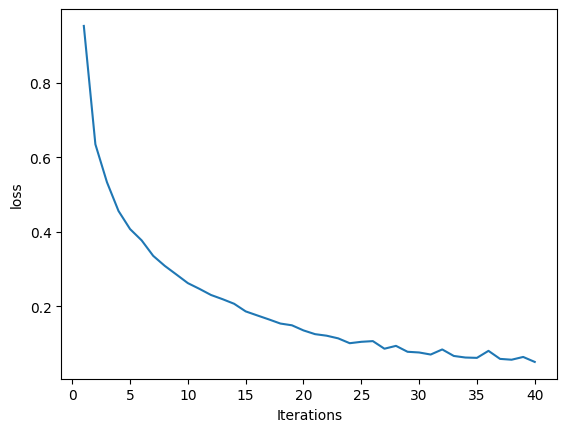

In [128]:
def plot_losses(losses):
    fig = plt.figure()

    ax = fig.add_subplot(1 , 1 , 1)

    ax.plot([i + 1 for i in range(len(losses))] , losses)
    ax.set_xlabel("Iterations")
    ax.set_ylabel('loss')
    plt.show()


plot_losses(losses)

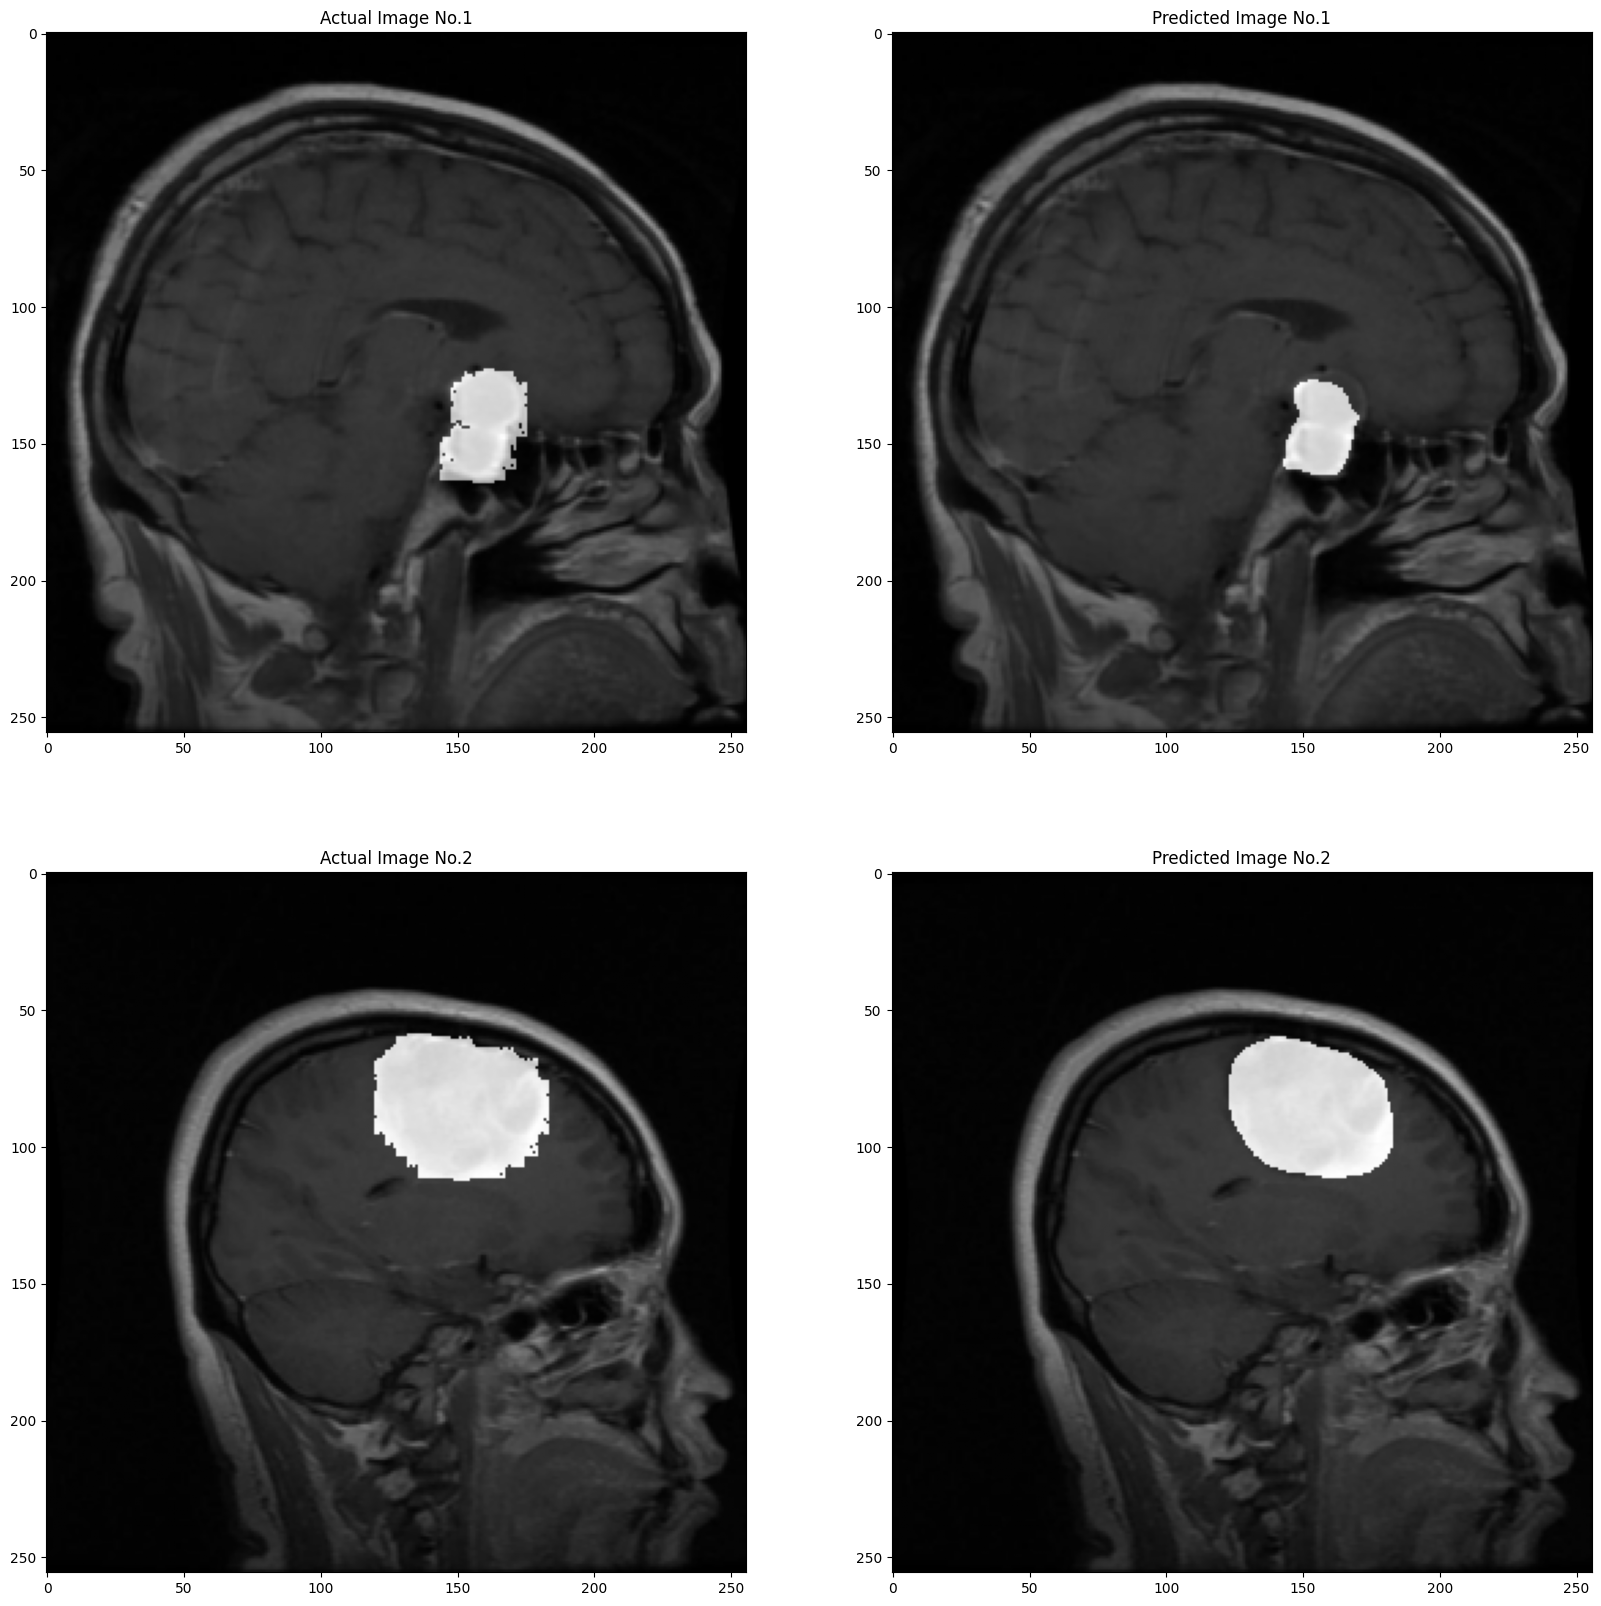

In [141]:
def process(image , mask):
        np_image = np.array(image) * 255
        np_image = np_image.reshape((np_image.shape[1] , np_image.shape[2] , np_image.shape[0]))
        np_mask = np.array(mask)
        np_mask = np_mask.reshape((np_mask.shape[1] , np_mask.shape[2] , np_mask.shape[0]))
        np_mask = (np_mask > 0 ).astype('int') * 255

        return np_image , np_mask
def predict(model , image , threshold = 0.99):


    model_result = model(image.unsqueeze(0))
    sigmoid = nn.Sigmoid()

    result_1 = sigmoid(model_result)

    result_2 = (result_1 >= threshold).int()

    result_3 = result_2[0].permute(1 , 2 , 0)
    
    result_4 = np.array(result_3.to('cpu'))

    return result_4

def plot_predictions( model , test_dataset , N = 5 , seed = 1 , threshold = 0.99):
    fig = plt.figure(figsize = (10* N , 10 * N))
    np.random.seed(seed)
    random_indices = np.random.randint(0 , len(test_dataset) , (N) , dtype = np.int32)
    
    for i in range(0 , N * 2 , 2):

        index = random_indices[int(i / 2)]
        ax = fig.add_subplot(N , 2 , i + 1)
        data = test_dataset[index]
        image = data[0]
        mask = data[1]
        
        np_image , np_mask = process(image , mask)
        ax.set_title(f"Actual Image No.{int(i/2 + 1)}")
        ax.imshow(np_image + np_mask, cmap = 'gray') 

        
        ay = fig.add_subplot(N , 2 , i + 2)
        pre_mask = predict(model , image , threshold = threshold)
        result_mask = pre_mask * 255
        ay.set_title(f"Predicted Image No.{int(i/2 + 1)}")
        ay.imshow(np_image + result_mask , cmap = 'gray')
    
    plt.show()

plot_predictions(model , test_dataset  , N = 2 , seed = 0 , threshold = 0.99)

In [147]:
def save_model(model , filename = "Segmentation_model.pk"):
    with open(os.path.join(OUTPUT_DIR , filename) , 'bw') as f:
        pk.dump(model , f)

save_model(model)